# From hydrocarbon phase evolution to reservoir production
### NeqSim + OPM Flow · a synthetic demonstration for issue #4198

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/notebooks/phase-evolution-opm-4198/notebooks/reservoir/phase_evolution_neqsim_opm_4198.ipynb)

**Questions:** How do composition, temperature, and pressure change hydrocarbon phase state?
What changes when gas is removed during depletion? How can NeqSim PVT calculations supply an
OPM Flow reservoir simulation, and how does pressure support affect gas liberation and production?

The notebook executes saturation-pressure, constant-mass-expansion (CCE), constant-volume-depletion
(CVD), and differential-liberation (DLE) experiments. It then runs **two real OPM Flow cases**
using NeqSim-generated black-oil tables, with retained production curves and reservoir-state maps.

The inspiration is [NeqSim issue #4198](https://github.com/equinor/neqsim/issues/4198) and
[Xu et al., Applied Sciences 15 (2025), 9694](https://doi.org/10.3390/app15179694).
Their study connects basin history, migration, and phase evolution in the Mo-Yong area.
**Every fluid, rock property, well control, and production result below is synthetic.**
This is a reproducible set of modeling building blocks, not a reproduction or validation of that field study.

## What is modeled—and what remains outside this example

| Question | Executed here | Boundary |
|---|---|---|
| Phase state along a pressure–temperature path | NeqSim SRK equilibrium flashes | No hydrocarbon generation, cracking, or migration kinetics |
| Closed-cell expansion | `SaturationPressure`, `ConstantMassExpansion` | No fluid leaves the CCE cell |
| Gas removal and retrograde liquid dropout | `ConstantVolumeDepletion` with material-balance checks | A laboratory cell, not a spatial reservoir model |
| Reservoir production and pressure support | OPM Flow, 300 cells, two wells, 36 monthly steps | Synthetic live-oil sector; fixed reservoir temperature |
| Condensate transport through porous rock | Discussed as an extension | The oil `PVTO/PVDG` deck does **not** represent condensate dropout |

The compositional model and black-oil model have different information content. The gas-condensate
example stays in NeqSim; exporting it through the oil deck would discard vaporized-oil physics.
A condensate field extension requires a qualified `PVTG`/vaporized-oil or compositional formulation.

Pressures are absolute (bara), temperatures are °C unless explicitly K, and standard volumes use
15°C and 1.01325 bara. Black-oil viscosities in the deck are cP. All cases use public software and
synthetic inputs. Initial Colab setup builds NeqSim master and installs OPM Flow; allow several minutes.

In [1]:
import importlib.metadata
import os
from pathlib import Path
import re
import shutil
import subprocess
import sys

required = {"neqsim": "3.23.0", "opm": "2026.4"}
missing = []
for package, expected in required.items():
    try:
        actual = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        actual = None
    if actual != expected:
        missing.append(f"{package}=={expected}")
if missing:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing],
        check=True, timeout=900,
    )

FLOW_EXECUTABLE = os.environ.get("OPM_FLOW_EXECUTABLE") or shutil.which("flow")
if FLOW_EXECUTABLE is None:
    if "Ubuntu" not in Path("/etc/os-release").read_text():
        raise RuntimeError("Use an Ubuntu/Colab runtime, or provide OPM_FLOW_EXECUTABLE.")
    privilege = [] if os.geteuid() == 0 else ["sudo"]
    commands = [
        ["apt-get", "update", "-qq"],
        ["apt-get", "install", "-y", "-qq", "software-properties-common", "mpi-default-bin"],
        ["add-apt-repository", "-y", "ppa:opm/ppa"],
        ["apt-get", "update", "-qq"],
        ["apt-get", "install", "-y", "-qq", "libopm-simulators-bin", "python3-opm-common"],
    ]
    for command in commands:
        result = subprocess.run(
            privilege + command, capture_output=True, text=True, timeout=1200,
        )
        if result.returncode:
            raise RuntimeError(result.stdout[-2000:] + result.stderr[-4000:])
    FLOW_EXECUTABLE = shutil.which("flow")
assert FLOW_EXECUTABLE, "OPM Flow was not installed successfully."
FLOW_RUN_ENV = os.environ.copy()
FLOW_RUN_ENV["OMP_NUM_THREADS"] = "1"
FLOW_RUN_ENV["OPENBLAS_NUM_THREADS"] = "1"
FLOW_RUN_ENV["OMPI_ALLOW_RUN_AS_ROOT"] = "1"
FLOW_RUN_ENV["OMPI_ALLOW_RUN_AS_ROOT_CONFIRM"] = "1"
flow_version = subprocess.run(
    [FLOW_EXECUTABLE, "--version"], env=FLOW_RUN_ENV,
    capture_output=True, text=True, check=True, timeout=60,
)
flow_version_text = (flow_version.stdout + flow_version.stderr).strip()
print("Python:", sys.version.split()[0])
print("Python packages:", required)
print("OPM executable:", flow_version_text)

Python: 3.12.14
Python packages: {'neqsim': '3.23.0', 'opm': '2026.4'}
OPM executable: flow 2026.04


## Build and identify the actual NeqSim Java runtime

The Python package supplies the bridge. Calculations load the source-built Java JAR first.
The default is current `master`; the resolved commit, JAR digest, and loaded class location are
printed so a run can be reproduced. A validation worker may supply an exact prebuilt source/JAR pair.

In [2]:
import hashlib
import importlib.util
import jpype


def run_command(command, *, cwd=None, timeout=1800, environment=None):
    result = subprocess.run(
        command,
        cwd=cwd,
        env=environment,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    if result.returncode != 0:
        tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(f"Command failed ({result.returncode}): {command}\n{tail}")
    return result.stdout.strip()


NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_source = os.environ.get("NEQSIM_SOURCE_ROOT", "").strip()
supplied_jar = os.environ.get("NEQSIM_SOURCE_JAR", "").strip()

if supplied_source and supplied_jar:
    neqsim_source = Path(supplied_source).resolve()
    neqsim_jar = Path(supplied_jar).resolve()
else:
    build_root = (
        Path("/content") if Path("/content").exists()
        else Path(os.environ.get("RUNNER_TEMP", "/tmp")).resolve()
    )
    neqsim_source = build_root / "neqsim-java-master"
    if not neqsim_source.exists():
        run_command(
            [
                "git", "clone", "--depth", "1", "--branch", NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git", str(neqsim_source),
            ],
            timeout=600,
        )
    else:
        run_command(["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
                    cwd=neqsim_source, timeout=600)
        run_command(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=neqsim_source)

    maven_settings = build_root / "neqsim-maven-settings.xml"
    maven_settings.write_text(
        "<settings><mirrors><mirror><id>canonical-central</id>"
        "<mirrorOf>central</mirrorOf>"
        "<url>https://repo.maven.apache.org/maven2/</url>"
        "</mirror></mirrors></settings>",
        encoding="utf-8",
    )
    run_command(
        [
            "./mvnw", "-q", "-s", str(maven_settings), "-DskipTests",
            "-Dmaven.javadoc.skip=true", "-Dmaven.test.skip=true", "package",
        ],
        cwd=neqsim_source,
        timeout=2400,
    )
    built_jars = [
        path for path in (neqsim_source / "target").glob("neqsim-*.jar")
        if "sources" not in path.name
        and "javadoc" not in path.name
        and not path.name.startswith("original-")
    ]
    if not built_jars:
        raise FileNotFoundError("Maven completed but no NeqSim JAR was found.")
    neqsim_jar = max(built_jars, key=lambda path: path.stat().st_size)

if not neqsim_source.is_dir() or not neqsim_jar.is_file():
    raise FileNotFoundError("NeqSim source root or built JAR is missing.")

neqsim_commit = run_command(["git", "rev-parse", "HEAD"], cwd=neqsim_source)
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if not jpype.isJVMStarted():
    jpype.addClassPath(str(neqsim_jar))
    neqsim_package = importlib.util.find_spec("neqsim")
    if neqsim_package is None or not neqsim_package.submodule_search_locations:
        raise ImportError("The public-PyPI neqsim bridge is not installed.")
    jpype.startJVM()

SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
class_source = str(
    SystemSrkEos.class_.getProtectionDomain().getCodeSource().getLocation()
)
if neqsim_jar.name not in class_source:
    raise RuntimeError("NeqSim classes were not loaded from the source-built JAR.")

print("NeqSim source ref:", NEQSIM_SOURCE_REF)
print("NeqSim resolved commit:", neqsim_commit)
print("NeqSim JAR SHA-256:", neqsim_jar_sha256)
print("Loaded class source:", class_source)



MainOnlyCapability = jpype.JClass("neqsim.process.equipment.tank.MountainCavern")
main_class_source = str(
    MainOnlyCapability.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert main_class_source == class_source
assert not run_command(["git", "status", "--porcelain", "--untracked-files=no"], cwd=neqsim_source)
print("Current-master capability resolved from the same JAR:", main_class_source)

NeqSim source ref: master
NeqSim resolved commit: 4a0c9b93218cd77c3137ee53cffcd83050d8dfca
NeqSim JAR SHA-256: 77f98ddec383f36373402cc4bcadd7d4a73f10d93ce96e18bfde7af28eca5219
Loaded class source: file:/workspace/scratch/bf0ebe8b6824/neqsim-master-4198/target/neqsim-3.23.0.jar
Current-master capability resolved from the same JAR: file:/workspace/scratch/bf0ebe8b6824/neqsim-master-4198/target/neqsim-3.23.0.jar


In [3]:
import json
import math

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
from jpype import JClass
from neqsim import jneqsim
from neqsim.thermo import TPflash
from opm.io import Parser
from opm.io.ecl import EclFile, EGrid, ERst, ESmry


plt.style.use("seaborn-v0_8-whitegrid")

RESERVOIR_TEMPERATURE_C = 97.5
RESERVOIR_TEMPERATURE_K = RESERVOIR_TEMPERATURE_C + 273.15
STANDARD_TEMPERATURE_C = 15.0
STANDARD_PRESSURE_BARA = 1.01325
INITIAL_RESERVOIR_PRESSURE_BARA = 260.0
PRODUCER_BHP_LIMIT_BARA = 80.0
SECONDS_PER_DAY = 86400.0

DLE_PRESSURES_BARA = np.array(
    [300.0, 250.0, 220.0, 200.0, 180.0, 150.0, 100.0, 50.0, 1.01325]
)
GAS_PVT_PRESSURES_BARA = np.array(
    [
        1.01325,
        25.0,
        50.0,
        75.0,
        100.0,
        125.0,
        150.0,
        175.0,
        200.0,
        225.0,
        250.0,
        275.0,
        300.0,
    ]
)

OUTPUT_DIRECTORY = Path("phase_evolution_4198_outputs").resolve()
OUTPUT_DIRECTORY.mkdir(exist_ok=True)

model_basis = pd.DataFrame(
    {
        "quantity": [
            "reservoir temperature",
            "initial reservoir pressure",
            "standard temperature",
            "standard pressure",
            "grid cells",
            "forecast length",
        ],
        "value": [97.5, 260.0, 15.0, 1.01325, 300, 36],
        "unit": ["°C", "bara", "°C", "bara", "count", "months"],
    }
)
display(model_basis)

def show_figure(figure, name):
    figure.savefig(OUTPUT_DIRECTORY / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()

,quantity,value,unit
0,reservoir temperature,97.50000,°C
1,initial reservoir pressure,260.00000,bara
2,standard temperature,15.00000,°C
3,standard pressure,1.01325,bara
4,grid cells,300.00000,count
5,forecast length,36.00000,months


## 1. Define and audit a synthetic live oil

The oil assay includes measured-component names, synthetic TBP cuts, and a C20+ fraction.
NeqSim characterizes the plus fraction into pseudocomponents. SRK, classic mixing, and volume
correction are explicit. This fluid is used in the oil-sector simulation; none of its values
are attributed to the Mo-Yong paper. Component amounts are mol%, molar masses kg/mol, and TBP
relative densities are dimensionless.

In [4]:
LIGHT_COMPONENTS = [
    ("nitrogen", 0.39),
    ("CO2", 0.30),
    ("methane", 40.20),
    ("ethane", 7.61),
    ("propane", 7.95),
    ("i-butane", 1.19),
    ("n-butane", 4.08),
    ("i-pentane", 1.39),
    ("n-pentane", 2.15),
    ("n-hexane", 2.79),
]

TBP_CUTS = [
    ("C7", 4.28, 0.095, 0.729),
    ("C8", 4.31, 0.106, 0.749),
    ("C9", 3.08, 0.121, 0.770),
    ("C10", 2.47, 0.135, 0.786),
    ("C11", 1.91, 0.148, 0.792),
    ("C12", 1.69, 0.161, 0.804),
    ("C13", 1.59, 0.175, 0.819),
    ("C14", 1.22, 0.196, 0.833),
    ("C15", 1.25, 0.206, 0.836),
    ("C16", 1.00, 0.225, 0.843),
    ("C17", 0.99, 0.236, 0.840),
    ("C18", 0.92, 0.245, 0.846),
    ("C19", 0.60, 0.265, 0.857),
]

PLUS_FRACTION = ("C20", 6.64, 0.453, 0.918)


def build_reservoir_fluid():
    fluid_model = jneqsim.thermo.system.SystemSrkEos(
        RESERVOIR_TEMPERATURE_K,
        INITIAL_RESERVOIR_PRESSURE_BARA,
    )

    for component_name, amount_mol_percent in LIGHT_COMPONENTS:
        fluid_model.addComponent(component_name, amount_mol_percent)

    for cut_name, amount, molar_mass, relative_density in TBP_CUTS:
        fluid_model.addTBPfraction(
            cut_name,
            amount,
            molar_mass,
            relative_density,
        )

    plus_name, plus_amount, plus_molar_mass, plus_density = PLUS_FRACTION
    fluid_model.addPlusFraction(
        plus_name,
        plus_amount,
        plus_molar_mass,
        plus_density,
    )

    characterization = fluid_model.getCharacterization()
    characterization.getLumpingModel().setNumberOfPseudoComponents(12)
    characterization.characterisePlusFraction()

    fluid_model.setMixingRule("classic")
    fluid_model.useVolumeCorrection(True)
    fluid_model.init(0)
    fluid_model.init(1)
    return fluid_model


reservoir_fluid = build_reservoir_fluid()

In [5]:
characterized_rows = []
for component_index in range(reservoir_fluid.getNumberOfComponents()):
    component = reservoir_fluid.getComponent(component_index)
    characterized_rows.append(
        {
            "component": str(component.getComponentName()),
            "mole_fraction": float(component.getz()),
            "molar_mass_g_mol": 1000.0 * float(component.getMolarMass()),
        }
    )

characterized_composition = pd.DataFrame(characterized_rows)
composition_sum = characterized_composition["mole_fraction"].sum()

initial_state = reservoir_fluid.clone()
initial_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
initial_state.setPressure(INITIAL_RESERVOIR_PRESSURE_BARA, "bara")
TPflash(initial_state)
initial_state.initProperties()

SaturationPressure = jneqsim.pvtsimulation.simulation.SaturationPressure
saturation_calculation = SaturationPressure(reservoir_fluid.clone())
saturation_calculation.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
saturation_calculation.run()
bubble_pressure_reference_bara = (
    saturation_calculation.getSaturationPressure()
)

fluid_audit = pd.DataFrame(
    {
        "quantity": [
            "input assay closure",
            "characterized components",
            "characterized composition sum",
            "initial phase count",
            "bubble pressure",
        ],
        "value": [
            sum(amount for _, amount in LIGHT_COMPONENTS)
            + sum(row[1] for row in TBP_CUTS)
            + PLUS_FRACTION[1],
            reservoir_fluid.getNumberOfComponents(),
            composition_sum,
            initial_state.getNumberOfPhases(),
            bubble_pressure_reference_bara,
        ],
        "unit": ["mol%", "count", "mol/mol", "count", "bara"],
    }
)
display(fluid_audit)
display(characterized_composition)

,quantity,value,unit
0,input assay closure,100.000000,mol%
1,characterized components,22.000000,count
2,characterized composition sum,1.000000,mol/mol
3,initial phase count,1.000000,count
4,bubble pressure,193.240934,bara


,component,mole_fraction,molar_mass_g_mol
0,nitrogen,0.003900,28.013500
1,CO2,0.003000,44.010000
2,methane,0.402000,16.043000
3,ethane,0.076100,30.070000
4,propane,0.079500,44.097000
5,i-butane,0.011900,58.123000
6,n-butane,0.040800,58.123000
7,i-pentane,0.013900,72.151000
8,n-pentane,0.021500,72.150000
9,n-hexane,0.027900,86.177000


## 2. Contrast oil with a synthetic gas condensate

The second composition is deliberately richer in methane. Each temperature–pressure grid point
is a separate equilibrium calculation at unchanged bulk composition. Gas fraction is a **mole
fraction of the total fluid**, not reservoir gas saturation. No geological-time or kinetic model
is implied by moving across this grid.

The grid explicitly enables `setMultiPhaseCheck(True)`. During validation, the default flash
at 80°C and 350 bara returned an unbalanced single-gas state for this condensate; the multiphase
check recovered a balanced two-phase state. The reproducer is tracked in
[NeqSim #4202](https://github.com/equinor/neqsim/issues/4202). Every grid point is checked
for component closure. This setting does not replace comparison with experimental phase data.


Maximum component closure residual over 750 flashes: 5.241e-12


,component,mole_fraction
0,methane,0.85
1,ethane,0.05
2,propane,0.02
3,n-butane,0.01
4,n-hexane,0.02
5,n-decane,0.03
6,n-hexadecane,0.02


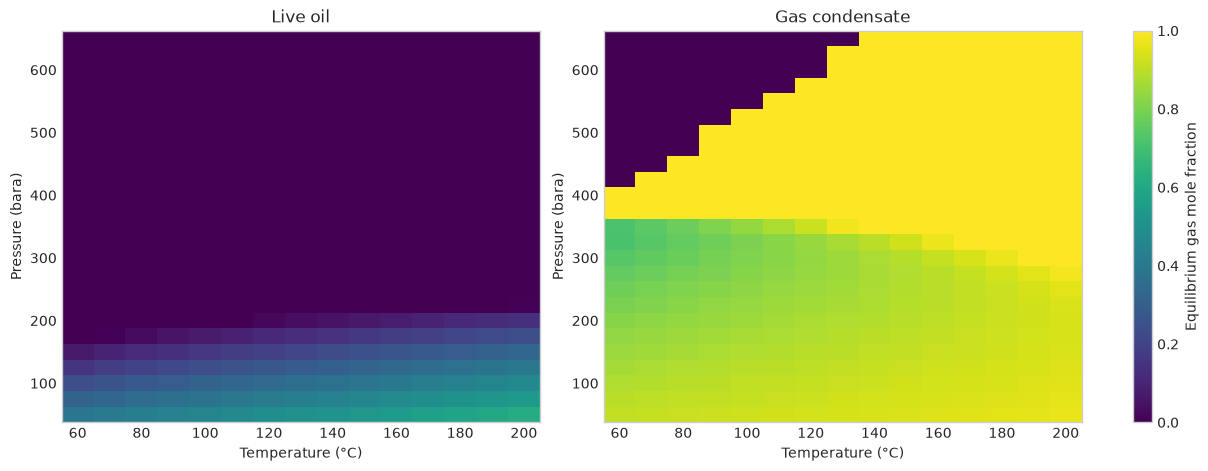

In [6]:
CONDENSATE_COMPOSITION = {
    "methane": 0.85, "ethane": 0.05, "propane": 0.02,
    "n-butane": 0.01, "n-hexane": 0.02,
    "n-decane": 0.03, "n-hexadecane": 0.02,
}

def build_condensate():
    fluid = JClass("neqsim.thermo.system.SystemSrkEos")(373.15, 500.0)
    for name, fraction in CONDENSATE_COMPOSITION.items():
        fluid.addComponent(name, fraction)
    fluid.setMixingRule("classic")
    fluid.useVolumeCorrection(True)
    return fluid

condensate = build_condensate()
assert abs(sum(CONDENSATE_COMPOSITION.values()) - 1.0) < 1e-12
display(pd.DataFrame({
    "component": CONDENSATE_COMPOSITION.keys(),
    "mole_fraction": CONDENSATE_COMPOSITION.values(),
}))
temperature_grid = np.linspace(60.0, 200.0, 15)
pressure_grid = np.linspace(50.0, 650.0, 25)
phase_maps = {}
maximum_component_residual = 0.0
for label, template in {"Live oil": reservoir_fluid, "Gas condensate": condensate}.items():
    gas_fraction = np.empty((len(pressure_grid), len(temperature_grid)))
    for pressure_index, pressure in enumerate(pressure_grid):
        for temperature_index, temperature in enumerate(temperature_grid):
            state = template.clone()
            state.setMultiPhaseCheck(True)
            state.setTemperature(float(temperature), "C")
            state.setPressure(float(pressure), "bara")
            TPflash(state)
            phase_count = state.getNumberOfPhases()
            gas_fraction[pressure_index, temperature_index] = sum(
                state.getBeta(index)
                for index in range(phase_count)
                if str(state.getPhase(index).getType()).lower() == "gas"
            )
            for component_index in range(state.getNumberOfComponents()):
                reconstructed = sum(
                    state.getBeta(index)
                    * state.getPhase(index).getComponent(component_index).getx()
                    for index in range(phase_count)
                )
                residual = abs(reconstructed - state.getComponent(component_index).getz())
                maximum_component_residual = max(maximum_component_residual, residual)
    phase_maps[label] = gas_fraction

figure, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
for axis, (label, gas_fraction) in zip(axes, phase_maps.items()):
    mesh = axis.pcolormesh(
        temperature_grid, pressure_grid, gas_fraction,
        shading="auto", cmap="viridis", vmin=0, vmax=1,
    )
    axis.set(title=label, xlabel="Temperature (°C)", ylabel="Pressure (bara)")
figure.colorbar(mesh, ax=axes, label="Equilibrium gas mole fraction")
show_figure(figure, "phase_state_maps")
print(f"Maximum component closure residual over 750 flashes: {maximum_component_residual:.3e}")

## 3. Saturation pressure and closed-cell expansion

`SaturationPressure` identifies the single-phase/two-phase boundary. The boundary is a bubble
point for this oil and a dew point for this condensate at 100°C. CCE retains all material while
pressure falls. Reported relative volume is total cell volume divided by the volume at saturation;
it is not a produced-volume fraction.

,fluid,temperature_C,saturation_pressure_bara,CCE_mole_balance_relative_error
0,Live oil,100.0,194.569298,0.0
1,Gas condensate,100.0,362.106749,0.0


,pressure_bara,Live oil,Gas condensate
0,500.0,0.930641,0.875666
1,400.0,0.947394,0.956859
2,350.0,0.957422,1.021962
3,300.0,0.968911,1.134426
4,250.0,0.982270,1.299539
5,200.0,0.998097,1.561641
6,150.0,1.122603,2.025587
7,100.0,1.443818,3.005654
8,50.0,2.585754,6.071053


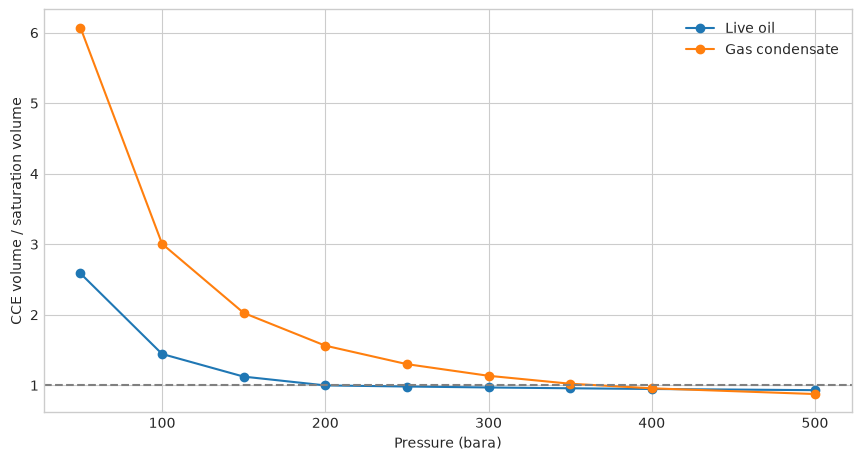

In [7]:
PVT_PRESSURES = np.array([500., 400., 350., 300., 250., 200., 150., 100., 50.])
cce_results = {}
saturation_rows = []
for label, template in {"Live oil": reservoir_fluid, "Gas condensate": condensate}.items():
    saturation = SaturationPressure(template.clone())
    saturation.setTemperature(100.0, "C")
    saturation.run()
    experiment = JClass("neqsim.pvtsimulation.simulation.ConstantMassExpansion")(
        template.clone()
    )
    experiment.setTemperature(100.0, "C")
    experiment.setPressures(PVT_PRESSURES.tolist())
    initial_moles = experiment.getThermoSystem().getTotalNumberOfMoles()
    experiment.runCalc()
    final_moles = experiment.getThermoSystem().getTotalNumberOfMoles()
    relative_volume = np.asarray(experiment.getRelativeVolume(), dtype=float)
    assert np.isfinite(relative_volume).all()
    assert abs(final_moles / initial_moles - 1.0) < 1e-10
    assert abs(experiment.getSaturationPressure() - saturation.getSaturationPressure()) < 0.2
    cce_results[label] = relative_volume
    saturation_rows.append({
        "fluid": label, "temperature_C": 100.0,
        "saturation_pressure_bara": float(saturation.getSaturationPressure()),
        "CCE_mole_balance_relative_error": abs(final_moles / initial_moles - 1.0),
    })
saturation_table = pd.DataFrame(saturation_rows)
display(saturation_table)
cce_table = pd.DataFrame({"pressure_bara": PVT_PRESSURES, **cce_results})
display(cce_table)
figure, axis = plt.subplots(figsize=(8.5, 4.5), constrained_layout=True)
for label, relative_volume in cce_results.items():
    axis.plot(PVT_PRESSURES, relative_volume, "o-", label=label)
axis.axhline(1.0, color="grey", linestyle="--")
axis.set(xlabel="Pressure (bara)", ylabel="CCE volume / saturation volume")
axis.legend()
show_figure(figure, "closed_cell_expansion")

## 4. Constant-volume depletion of the gas condensate

CVD removes equilibrium gas after each pressure reduction until the cell returns to its saturation
volume. Above the dew point the volume is below that reference and no gas is removed. Liquid dropout
is expressed as percent of the saturation-cell volume. The balance is

$$n_0=n_{\mathrm{remaining}}+n_{\mathrm{gas\ removed}}$$

where $n_0$ is the initial mole amount. The NeqSim CVD balance check is complemented by a volume
closure check below saturation and monotonically increasing cumulative depletion. These checks
establish internal consistency; they do not replace laboratory CVD measurements.

CVD material balance passed: True
Maximum cell-volume error: 1.243e-12


,pressure_bara,cell_volume_over_Vsat,liquid_volume_pct_Vsat,cumulative_mole_pct_removed
0,500.0,0.868638,0.000000,0.000000
1,400.0,0.954420,0.000000,0.000000
2,350.0,1.000000,16.889039,2.279495
3,300.0,1.000000,22.421466,12.505850
4,250.0,1.000000,21.320644,23.998012
5,200.0,1.000000,19.673522,36.789221
6,150.0,1.000000,17.977337,50.747066
7,100.0,1.000000,16.316940,65.483169
8,50.0,1.000000,14.654378,80.425770


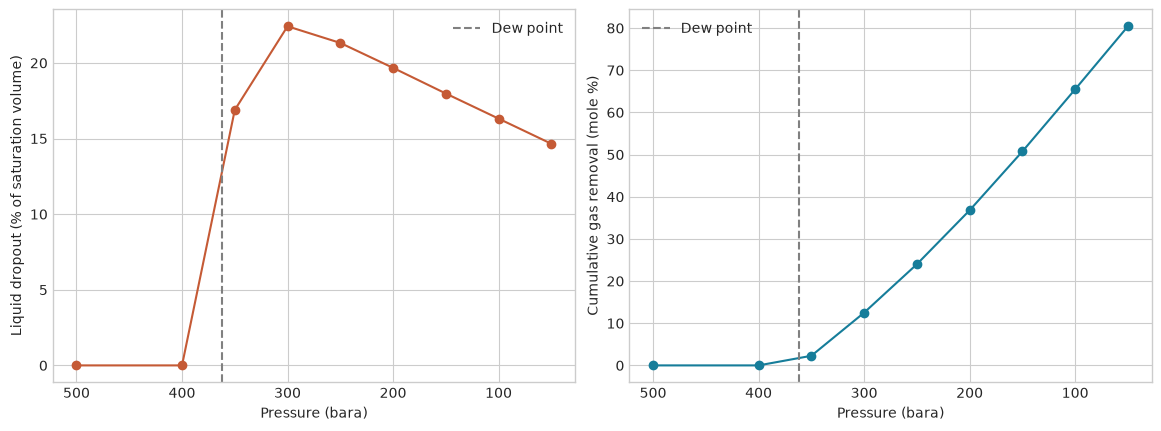

In [8]:
cvd = JClass("neqsim.pvtsimulation.simulation.ConstantVolumeDepletion")(condensate.clone())
cvd.setTemperature(100.0, "C")
cvd.setPressures(PVT_PRESSURES.tolist())
cvd.runCalc()
cvd_table = pd.DataFrame({
    "pressure_bara": PVT_PRESSURES,
    "cell_volume_over_Vsat": np.asarray(cvd.getRelativeVolume(), dtype=float),
    "liquid_volume_pct_Vsat": np.asarray(cvd.getLiquidRelativeVolume(), dtype=float),
    "cumulative_mole_pct_removed": np.asarray(cvd.getCummulativeMolePercDepleted(), dtype=float),
})
cvd_below_dew = PVT_PRESSURES < cvd.getSaturationPressure()
cvd_balance_passed = bool(cvd.validateMaterialBalance(1e-8))
cvd_volume_error = float(np.max(np.abs(
    cvd_table.loc[cvd_below_dew, "cell_volume_over_Vsat"] - 1.0
)))
assert cvd_balance_passed
assert cvd_volume_error < 1e-7
assert np.all(np.diff(cvd_table["cumulative_mole_pct_removed"]) >= -1e-8)
display(cvd_table)
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
axes[0].plot(PVT_PRESSURES, cvd_table["liquid_volume_pct_Vsat"], "o-", color="#c55a35")
axes[0].set(xlabel="Pressure (bara)", ylabel="Liquid dropout (% of saturation volume)")
axes[1].plot(PVT_PRESSURES, cvd_table["cumulative_mole_pct_removed"], "o-", color="#167d9a")
axes[1].set(xlabel="Pressure (bara)", ylabel="Cumulative gas removal (mole %)")
for axis in axes:
    axis.axvline(cvd.getSaturationPressure(), color="grey", linestyle="--", label="Dew point")
    axis.invert_xaxis()
    axis.legend()
show_figure(figure, "constant_volume_depletion")
print("CVD material balance passed:", cvd_balance_passed)
print(f"Maximum cell-volume error: {cvd_volume_error:.3e}")

## 5. Generate an oil PVT handoff for OPM Flow

The remaining workflow uses **only the live oil at 97.5°C**. DLE removes liberated gas successively;
its remaining liquid becomes heavier. The black-oil handoff uses

$$B_o=\frac{V_o(P,T_R)}{V_{o,\mathrm{sc}}},\qquad R_s=\frac{V_{g,\mathrm{sc}}}{V_{o,\mathrm{sc}}}$$

where $V_o$ is reservoir oil volume, $T_R$ reservoir temperature, and subscript sc indicates the
standard-volume basis. `PVTO` receives $R_s$, pressure, $B_o$, and oil viscosity. `PVDG` uses
standard-gas density divided by reservoir-gas density to calculate $B_g$. Water uses CPA.

**Teaching approximation:** the oil viscosity uses equilibrium flashes of the original oil
composition at each pressure, while DLE supplies $B_o$ and $R_s$. Dry-gas composition is fixed to
the stock-tank gas. There is one undersaturated continuation branch. This is a transparent
workflow demonstration, not a tuned field PVT model or a suitable gas-injection/miscibility model.

In [9]:
DifferentialLiberation = (
    jneqsim.pvtsimulation.simulation.DifferentialLiberation
)
dle = DifferentialLiberation(reservoir_fluid.clone())
dle.setPressures(DLE_PRESSURES_BARA.tolist())
dle.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
dle.runCalc()

bubble_pressure_bara = float(dle.getSaturationPressure())
dle_rs = np.asarray(dle.getRs(), dtype=float)
dle_bo = np.asarray(dle.getBo(), dtype=float)
dle_bg = np.asarray(dle.getBg(), dtype=float)
dle_oil_density_kg_m3 = np.asarray(dle.getOilDensity(), dtype=float)

saturation_gas_state = reservoir_fluid.clone()
saturation_gas_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
saturation_gas_state.setPressure(bubble_pressure_bara * 0.99, "bara")
TPflash(saturation_gas_state)
saturation_gas_state.initProperties()
saturation_gas_viscosity_pa_s = (
    saturation_gas_state.getPhase("gas").getViscosity("cP") / 1000.0
)

black_oil_rows = []
for pressure_bara, rs_value, bo_value, bg_value, oil_density in zip(
    DLE_PRESSURES_BARA,
    dle_rs,
    dle_bo,
    dle_bg,
    dle_oil_density_kg_m3,
):
    property_state = reservoir_fluid.clone()
    property_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    property_state.setPressure(float(pressure_bara), "bara")
    TPflash(property_state)
    property_state.initProperties()

    oil_viscosity_pa_s = (
        property_state.getPhase("oil").getViscosity("cP") / 1000.0
    )
    if property_state.hasPhaseType("gas"):
        gas_viscosity_pa_s = (
            property_state.getPhase("gas").getViscosity("cP") / 1000.0
        )
    else:
        gas_viscosity_pa_s = saturation_gas_viscosity_pa_s

    black_oil_rows.append(
        {
            "pressure_bara": float(pressure_bara),
            "Rs_Sm3_Sm3": float(rs_value),
            "Bo_rm3_Sm3": float(bo_value),
            "oil_density_kg_m3": float(oil_density),
            "oil_viscosity_cP": 1000.0 * float(oil_viscosity_pa_s),
            "DLE_Bg_rm3_Sm3": float(bg_value),
            "gas_viscosity_cP": 1000.0 * float(gas_viscosity_pa_s),
        }
    )

black_oil_source_table = pd.DataFrame(black_oil_rows)
display(black_oil_source_table)
print(f"DLE bubble pressure: {bubble_pressure_bara:.6f} bara")

DLE bubble pressure: 193.240400 bara


,pressure_bara,Rs_Sm3_Sm3,Bo_rm3_Sm3,oil_density_kg_m3,oil_viscosity_cP,DLE_Bg_rm3_Sm3,gas_viscosity_cP
0,300.00000,224.672710,1.764295,669.030434,0.251013,0.000000,0.021248
1,250.00000,224.672710,1.789529,659.596213,0.235980,0.000000,0.021248
2,220.00000,224.672710,1.806786,653.296398,0.226502,0.000000,0.021248
3,200.00000,224.672710,1.819362,648.780648,0.219967,0.000000,0.021248
4,180.00000,209.018245,1.779299,654.830015,0.230365,0.006301,0.020399
5,150.00000,176.526156,1.687488,672.151168,0.263080,0.007562,0.018454
6,100.00000,128.971246,1.552728,701.626800,0.336558,0.011533,0.015971
7,50.00000,86.277567,1.427528,733.148154,0.461901,0.023873,0.014126
8,1.01325,0.000000,1.050859,810.424578,1.955226,1.271652,0.011572


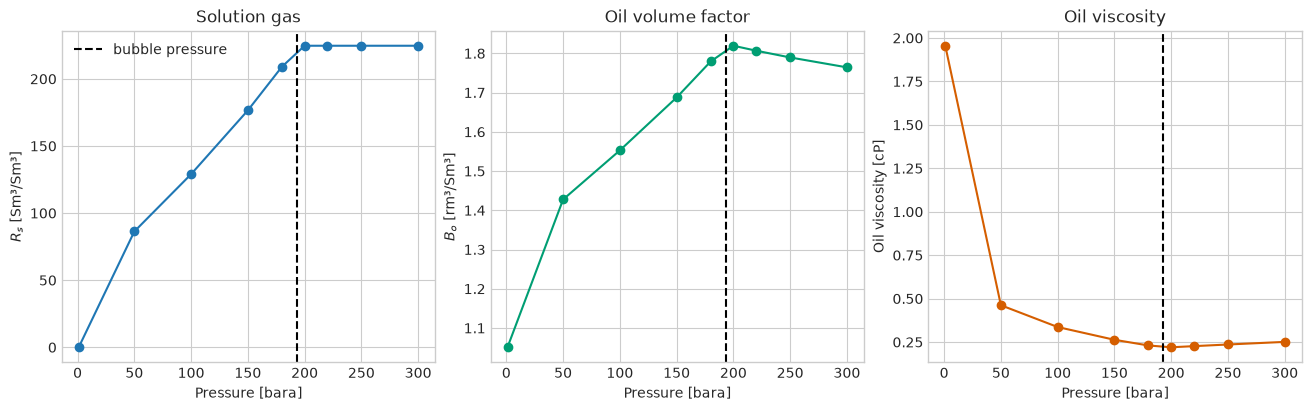

In [10]:
pvt_figure, pvt_axes = plt.subplots(
    1,
    3,
    figsize=(13.0, 4.0),
    constrained_layout=True,
)

pvt_axes[0].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["Rs_Sm3_Sm3"],
    marker="o",
)
pvt_axes[0].axvline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
    label="bubble pressure",
)
pvt_axes[0].set_xlabel("Pressure [bara]")
pvt_axes[0].set_ylabel("$R_s$ [Sm³/Sm³]")
pvt_axes[0].set_title("Solution gas")
pvt_axes[0].legend()

pvt_axes[1].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["Bo_rm3_Sm3"],
    marker="o",
    color="#009E73",
)
pvt_axes[1].axvline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
)
pvt_axes[1].set_xlabel("Pressure [bara]")
pvt_axes[1].set_ylabel("$B_o$ [rm³/Sm³]")
pvt_axes[1].set_title("Oil volume factor")

pvt_axes[2].plot(
    black_oil_source_table["pressure_bara"],
    black_oil_source_table["oil_viscosity_cP"],
    marker="o",
    color="#D55E00",
)
pvt_axes[2].axvline(
    bubble_pressure_bara,
    color="black",
    linestyle="--",
)
pvt_axes[2].set_xlabel("Pressure [bara]")
pvt_axes[2].set_ylabel("Oil viscosity [cP]")
pvt_axes[2].set_title("Oil viscosity")

pvt_plot_path = OUTPUT_DIRECTORY / "neqsim_black_oil_pvt.png"
pvt_figure.savefig(pvt_plot_path, dpi=150)
show_figure(pvt_figure, "oil_pvt")

In [11]:
stock_tank_state = reservoir_fluid.clone()
stock_tank_state.setTemperature(STANDARD_TEMPERATURE_C, "C")
stock_tank_state.setPressure(STANDARD_PRESSURE_BARA, "bara")
TPflash(stock_tank_state)
stock_tank_state.initProperties()

stock_oil_density_kg_m3 = (
    stock_tank_state.getPhase("oil").getDensity("kg/m3")
)
stock_gas_density_kg_m3 = (
    stock_tank_state.getPhase("gas").getDensity("kg/m3")
)

ArrayList = JClass("java.util.ArrayList")
BlackOilPVTTable = JClass("neqsim.blackoil.BlackOilPVTTable")
black_oil_records = ArrayList()
for row in black_oil_source_table.sort_values(
    "pressure_bara"
).to_dict("records"):
    black_oil_records.add(
        BlackOilPVTTable.Record(
            row["pressure_bara"],
            row["Rs_Sm3_Sm3"],
            row["Bo_rm3_Sm3"],
            row["oil_viscosity_cP"] / 1000.0,
            max(row["DLE_Bg_rm3_Sm3"], 1.0e-6),
            row["gas_viscosity_cP"] / 1000.0,
            0.0,
            1.0,
            1.0e-3,
        )
    )

black_oil_table = BlackOilPVTTable(
    black_oil_records,
    bubble_pressure_bara,
)

bubble_bo = float(
    np.interp(
        bubble_pressure_bara,
        np.sort(DLE_PRESSURES_BARA),
        dle_bo[np.argsort(DLE_PRESSURES_BARA)],
    )
)
bubble_state = reservoir_fluid.clone()
bubble_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
bubble_state.setPressure(bubble_pressure_bara, "bara")
TPflash(bubble_state)
bubble_state.initProperties()
bubble_oil_viscosity_cp = (
    bubble_state.getPhase("oil").getViscosity("cP")
)
maximum_solution_gor = float(np.max(dle_rs))

saturated_oil_rows = []
for row in black_oil_source_table.sort_values(
    "pressure_bara"
).to_dict("records"):
    if row["pressure_bara"] >= bubble_pressure_bara:
        continue
    if (
        saturated_oil_rows
        and row["Rs_Sm3_Sm3"] <= saturated_oil_rows[-1]["Rs"]
    ):
        continue
    saturated_oil_rows.append(
        {
            "Rs": max(row["Rs_Sm3_Sm3"], 1.0e-6),
            "pressure": row["pressure_bara"],
            "Bo": row["Bo_rm3_Sm3"],
            "mu_o": row["oil_viscosity_cP"],
        }
    )

saturated_oil_rows.append(
    {
        "Rs": maximum_solution_gor,
        "pressure": bubble_pressure_bara,
        "Bo": bubble_bo,
        "mu_o": bubble_oil_viscosity_cp,
    }
)

maximum_pressure_row = black_oil_source_table.loc[
    black_oil_source_table["pressure_bara"].idxmax()
]
undersaturated_oil_row = {
    "pressure": float(maximum_pressure_row["pressure_bara"]),
    "Bo": float(maximum_pressure_row["Bo_rm3_Sm3"]),
    "mu_o": float(maximum_pressure_row["oil_viscosity_cP"]),
}

In [12]:
stock_gas_template = stock_tank_state.phaseToSystem("gas")
dry_gas_rows = []
for pressure_bara in GAS_PVT_PRESSURES_BARA:
    gas_state = stock_gas_template.clone()
    gas_state.setTemperature(RESERVOIR_TEMPERATURE_C, "C")
    gas_state.setPressure(float(pressure_bara), "bara")
    TPflash(gas_state)
    gas_state.initProperties()
    gas_density_kg_m3 = gas_state.getPhase("gas").getDensity("kg/m3")
    dry_gas_rows.append(
        {
            "pressure_bara": float(pressure_bara),
            "Bg_rm3_Sm3": (
                stock_gas_density_kg_m3 / gas_density_kg_m3
            ),
            "gas_viscosity_cP": (
                gas_state.getPhase("gas").getViscosity("cP")
            ),
        }
    )

dry_gas_table = pd.DataFrame(dry_gas_rows)


def build_water_state(temperature_c, pressure_bara):
    water_state = jneqsim.thermo.system.SystemSrkCPAstatoil(
        temperature_c + 273.15,
        pressure_bara,
    )
    water_state.addComponent("water", 1.0)
    water_state.setMixingRule(10)
    TPflash(water_state)
    water_state.initProperties()
    return water_state


standard_water_state = build_water_state(
    STANDARD_TEMPERATURE_C,
    STANDARD_PRESSURE_BARA,
)
reference_water_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara,
)
water_low_pressure_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara - 1.0,
)
water_high_pressure_state = build_water_state(
    RESERVOIR_TEMPERATURE_C,
    bubble_pressure_bara + 1.0,
)

stock_water_density_kg_m3 = (
    standard_water_state.getPhase("aqueous").getDensity("kg/m3")
)
reservoir_water_density_kg_m3 = (
    reference_water_state.getPhase("aqueous").getDensity("kg/m3")
)
water_fvf = (
    stock_water_density_kg_m3 / reservoir_water_density_kg_m3
)
water_compressibility_per_bar = (
    water_high_pressure_state.getPhase("aqueous").getDensity("kg/m3")
    - water_low_pressure_state.getPhase("aqueous").getDensity("kg/m3")
) / (2.0 * reservoir_water_density_kg_m3)
water_viscosity_cp = (
    reference_water_state.getPhase("aqueous").getViscosity("cP")
)

display(dry_gas_table)
display(
    pd.DataFrame(
        {
            "water_property": [
                "stock-tank density",
                "reservoir density",
                "formation-volume factor",
                "compressibility",
                "viscosity",
            ],
            "value": [
                stock_water_density_kg_m3,
                reservoir_water_density_kg_m3,
                water_fvf,
                water_compressibility_per_bar,
                water_viscosity_cp,
            ],
            "unit": ["kg/m³", "kg/m³", "rm³/Sm³", "1/bar", "cP"],
        }
    )
)

,pressure_bara,Bg_rm3_Sm3,gas_viscosity_cP
0,1.01325,1.290646,0.012544
1,25.00000,0.049262,0.013143
2,50.00000,0.023145,0.014019
3,75.00000,0.014572,0.015213
4,100.00000,0.010446,0.016778
5,125.00000,0.008134,0.018700
6,150.00000,0.006733,0.020876
7,175.00000,0.005831,0.023164
8,200.00000,0.005216,0.025456
9,225.00000,0.004776,0.027697


,water_property,value,unit
0,stock-tank density,997.784768,kg/m³
1,reservoir density,978.587636,kg/m³
2,formation-volume factor,1.019617,rm³/Sm³
3,compressibility,0.000050,1/bar
4,viscosity,0.294506,cP


In [13]:
pvto_lines = ["PVTO"]
for row_index, row in enumerate(saturated_oil_rows):
    is_last_saturated_row = row_index == len(saturated_oil_rows) - 1
    row_suffix = "" if is_last_saturated_row else " /"
    pvto_lines.append(
        "  "
        f"{row['Rs']:.8f} "
        f"{row['pressure']:.8f} "
        f"{row['Bo']:.8f} "
        f"{row['mu_o']:.8f}"
        f"{row_suffix}"
    )
    if is_last_saturated_row:
        pvto_lines.append(
            "    "
            f"{undersaturated_oil_row['pressure']:.8f} "
            f"{undersaturated_oil_row['Bo']:.8f} "
            f"{undersaturated_oil_row['mu_o']:.8f} /"
        )
pvto_lines.append("/")

pvdg_lines = ["PVDG"]
for row_index, row in dry_gas_table.iterrows():
    row_suffix = " /" if row_index == len(dry_gas_table) - 1 else ""
    pvdg_lines.append(
        "  "
        f"{row['pressure_bara']:.8f} "
        f"{row['Bg_rm3_Sm3']:.10f} "
        f"{row['gas_viscosity_cP']:.8f}"
        f"{row_suffix}"
    )

black_oil_include = "\n".join(
    [
        "-- Flow-compatible black-oil tables calculated with NeqSim",
        "-- Pressure is absolute and the table unit system is METRIC.",
        "DENSITY",
        "  "
        f"{stock_oil_density_kg_m3:.8f} "
        f"{stock_water_density_kg_m3:.8f} "
        f"{stock_gas_density_kg_m3:.8f} /",
        "",
        *pvto_lines,
        "",
        *pvdg_lines,
        "",
        "PVTW",
        "  "
        f"{bubble_pressure_bara:.8f} "
        f"{water_fvf:.8f} "
        f"{water_compressibility_per_bar:.10e} "
        f"{water_viscosity_cp:.8f} "
        "0.0 /",
        "",
    ]
)

black_oil_path = OUTPUT_DIRECTORY / "NEQSIM_PVT.INC"
black_oil_path.write_text(black_oil_include, encoding="utf-8")

oil_table_audit = pd.DataFrame(saturated_oil_rows)
display(oil_table_audit)
print("\n".join(black_oil_include.splitlines()[:42]))
print(f"Black-oil include: {black_oil_path}")

-- Flow-compatible black-oil tables calculated with NeqSim
-- Pressure is absolute and the table unit system is METRIC.
DENSITY
  832.46987287 997.78476781 1.12375584 /

PVTO
  0.00000100 1.01325000 1.05085900 1.95522636 /
  86.27756659 50.00000000 1.42752753 0.46190091 /
  128.97124554 100.00000000 1.55272761 0.33655787 /
  176.52615626 150.00000000 1.68748770 0.26307966 /
  209.01824465 180.00000000 1.77929947 0.23036455 /
  224.67271009 193.24040031 1.80582153 0.21771608
    300.00000000 1.76429452 0.25101335 /
/

PVDG
  1.01325000 1.2906458622 0.01254417
  25.00000000 0.0492622652 0.01314293
  50.00000000 0.0231449092 0.01401858
  75.00000000 0.0145720509 0.01521278
  100.00000000 0.0104455093 0.01677753
  125.00000000 0.0081343925 0.01870015
  150.00000000 0.0067329734 0.02087585
  175.00000000 0.0058305684 0.02316351
  200.00000000 0.0052160944 0.02545613
  225.00000000 0.0047757014 0.02769676
  250.00000000 0.0044458169 0.02986229
  275.00000000 0.0041894725 0.03194685
  300.000

,Rs,pressure,Bo,mu_o
0,0.000001,1.01325,1.050859,1.955226
1,86.277567,50.00000,1.427528,0.461901
2,128.971246,100.00000,1.552728,0.336558
3,176.526156,150.00000,1.687488,0.263080
4,209.018245,180.00000,1.779299,0.230365
5,224.672710,193.24040,1.805822,0.217716


## 6. Build the same 300-cell reservoir for two pressure-support scenarios

The 1 km × 1 km × 30 m sector has three permeability layers, 25% porosity, a producer and a water
injector. It starts at 260 bara at 2500 m. Oil-rate target is 1500 Sm³/day; producer BHP cannot
fall below 80 bara. The injector is pressure-limited to 285 bara. Compare water-injection targets
of 300 and 1200 Sm³/day with all other inputs held fixed.

This production-scale model is intentionally separate from the high-pressure phase-state grid.
It cannot reconstruct deep-basin burial, source-rock maturation, fault opening, or migration history.
Relative-permeability curves, contacts, permeability, and rock compressibility are synthetic.

In [14]:
relative_permeability_tables = """
SWOF
  0.12  0.00000  1.0000  0.0
  0.20  0.00010  0.8500  0.0
  0.30  0.00100  0.6200  0.0
  0.40  0.00800  0.4000  0.0
  0.50  0.03000  0.2200  0.0
  0.60  0.09000  0.1000  0.0
  0.70  0.22000  0.0300  0.0
  0.80  0.48000  0.0050  0.0
  0.88  1.00000  0.0000  0.0 /

SGOF
  0.00  0.0000  1.0000  0.0
  0.05  0.0020  0.9300  0.0
  0.10  0.0100  0.8000  0.0
  0.20  0.0600  0.5500  0.0
  0.30  0.1600  0.3200  0.0
  0.40  0.3300  0.1500  0.0
  0.50  0.5500  0.0500  0.0
  0.60  0.7800  0.0100  0.0
  0.70  0.9300  0.0010  0.0
  0.88  1.0000  0.0000  0.0 /
""".strip()

initial_rs_sm3_sm3 = saturated_oil_rows[-1]["Rs"]

deck_text = f"""
RUNSPEC
TITLE
  NEQSIM CHARACTERIZED BLACK-OIL MODEL WITH OPM FLOW

DIMENS
  10 10 3 /

OIL
GAS
WATER
DISGAS
METRIC

START
  1 'JAN' 2026 /

WELLDIMS
  2 3 1 2 /

TABDIMS
/

EQLDIMS
/

UNIFOUT

GRID
INIT
DX
  300*100.0 /
DY
  300*100.0 /
DZ
  100*5.0 100*10.0 100*15.0 /
TOPS
  100*2500.0 /
PORO
  300*0.25 /
PERMX
  100*300.0 100*75.0 100*150.0 /
PERMY
  100*300.0 100*75.0 100*150.0 /
PERMZ
  100*30.0 100*7.5 100*15.0 /

PROPS
INCLUDE
  'NEQSIM_PVT.INC' /

ROCK
  260.0 4.0E-5 /

{relative_permeability_tables}

SOLUTION
EQUIL
  2500.0 260.0 2550.0 0.0 2450.0 0.0 1 0 0 /

RSVD
  2450.0 {initial_rs_sm3_sm3:.8f}
  2550.0 {initial_rs_sm3_sm3:.8f} /

SUMMARY
FPR
FOPR
FGPR
FWPR
FOPT
FGPT
FWPT
WBHP
  'PROD' /
WOPR
  'PROD' /
WGPR
  'PROD' /
WWPR
  'PROD' /
WGOR
  'PROD' /

SCHEDULE
RPTRST
  'BASIC=1' /

GRUPTREE
  'WELLS' 'FIELD' /
/

WELSPECS
  'PROD' 'WELLS' 10 10 2515.0 'OIL' /
  'WINJ' 'WELLS' 7 10 2503.0 'WATER' /
/

COMPDAT
  'PROD' 10 10 1 3 'OPEN' 1* 1* 0.20 /
  'WINJ' 7 10 1 3 'OPEN' 1* 1* 0.20 /
/

WCONPROD
  'PROD' 'OPEN' 'ORAT' 1500.0 4* 80.0 /
/

WCONINJE
  'WINJ' 'WATER' 'OPEN' 'RATE' 300.0 1* 285.0 /
/

TSTEP
  36*30.4375 /

END
""".strip()

deck_path = OUTPUT_DIRECTORY / "NEQSIM_OPM.DATA"
deck_path.write_text(deck_text + "\n", encoding="utf-8")
print(f"Flow deck: {deck_path}")
print(f"Deck lines: {len(deck_text.splitlines())}")

Flow deck: /workspace/scratch/bf0ebe8b6824/colab-4198/phase_evolution_4198_outputs/NEQSIM_OPM.DATA
Deck lines: 133


In [15]:
parsed_deck = Parser().parse(str(deck_path))
required_deck_keywords = [
    "DIMENS",
    "DENSITY",
    "PVTO",
    "PVDG",
    "PVTW",
    "EQUIL",
    "WELSPECS",
    "WCONPROD",
    "WCONINJE",
]
deck_keyword_audit = pd.DataFrame(
    {
        "keyword": required_deck_keywords,
        "present": [
            keyword in parsed_deck
            for keyword in required_deck_keywords
        ],
    }
)

oil_rs_values = oil_table_audit["Rs"].to_numpy()
oil_bubble_pressures = oil_table_audit["pressure"].to_numpy()
gas_pressures = dry_gas_table["pressure_bara"].to_numpy()
gas_bg_values = dry_gas_table["Bg_rm3_Sm3"].to_numpy()

pvt_contract_audit = pd.DataFrame(
    {
        "contract": [
            "saturated Rs strictly increases",
            "bubble pressure strictly increases",
            "dry-gas pressure strictly increases",
            "dry-gas Bg strictly decreases",
            "undersaturated Bo decreases with pressure",
            "undersaturated viscosity increases with pressure",
            "no invalid numeric tokens",
        ],
        "passed": [
            np.all(np.diff(oil_rs_values) > 0.0),
            np.all(np.diff(oil_bubble_pressures) > 0.0),
            np.all(np.diff(gas_pressures) > 0.0),
            np.all(np.diff(gas_bg_values) < 0.0),
            undersaturated_oil_row["Bo"] < saturated_oil_rows[-1]["Bo"],
            (
                undersaturated_oil_row["mu_o"]
                > saturated_oil_rows[-1]["mu_o"]
            ),
            not any(
                token in black_oil_include
                for token in ["NaN", "Infinity", "-Infinity"]
            ),
        ],
    }
)

display(deck_keyword_audit)
display(pvt_contract_audit)
print(f"OPM parser accepted {len(parsed_deck)} deck keywords.")

OPM parser accepted 55 deck keywords.


,keyword,present
0,DIMENS,True
1,DENSITY,True
2,PVTO,True
3,PVDG,True
4,PVTW,True
5,EQUIL,True
6,WELSPECS,True
7,WCONPROD,True
8,WCONINJE,True


,contract,passed
0,saturated Rs strictly increases,True
1,bubble pressure strictly increases,True
2,dry-gas pressure strictly increases,True
3,dry-gas Bg strictly decreases,True
4,undersaturated Bo decreases with pressure,True
5,undersaturated viscosity increases with pressure,True
6,no invalid numeric tokens,True


## 7. Execute both cases and retain simulator diagnostics

Each case gets its own deck, PVT include, logs, summary, and restart files. A nonzero Flow return
code stops the notebook. No stored-output substitution or analytical forecast replaces Flow.

In [16]:
import time

scenario_histories = {}
scenario_directories = {}
scenario_diagnostics = []
for label, injection_rate in {"Weak support": 300.0, "Strong support": 1200.0}.items():
    case_name = label.lower().replace(" ", "_")
    case_directory = OUTPUT_DIRECTORY / case_name
    case_directory.mkdir(exist_ok=True)
    case_deck = deck_text.replace(
        "'RATE' 300.0 1* 285.0", f"'RATE' {injection_rate:.1f} 1* 285.0"
    )
    (case_directory / "NEQSIM_OPM.DATA").write_text(case_deck + "\n")
    (case_directory / "NEQSIM_PVT.INC").write_text(black_oil_include)
    Parser().parse(str(case_directory / "NEQSIM_OPM.DATA"))
    started = time.perf_counter()
    completed = subprocess.run(
        [FLOW_EXECUTABLE, "NEQSIM_OPM.DATA"], cwd=case_directory,
        env=FLOW_RUN_ENV, capture_output=True, text=True, timeout=600,
    )
    (case_directory / "flow_stdout.log").write_text(completed.stdout)
    (case_directory / "flow_stderr.log").write_text(completed.stderr)
    if completed.returncode:
        raise RuntimeError(completed.stdout[-6000:] + completed.stderr[-3000:])
    summary = ESmry(str(case_directory / "NEQSIM_OPM.SMSPEC"))
    vectors = {
        "days": "TIME", "pressure_bara": "FPR", "oil_Sm3_day": "FOPR",
        "gas_Sm3_day": "FGPR", "water_Sm3_day": "FWPR",
        "oil_cumulative_Sm3": "FOPT", "gas_cumulative_Sm3": "FGPT",
        "water_cumulative_Sm3": "FWPT", "bhp_bara": "WBHP:PROD",
        "gor_Sm3_Sm3": "WGOR:PROD",
    }
    history = pd.DataFrame({name: np.asarray(summary[key]) for name, key in vectors.items()})
    history.to_csv(case_directory / "production_history.csv", index=False)
    scenario_histories[label] = history
    scenario_directories[label] = case_directory
    scenario_diagnostics.append({
        "case": label, "injection_target_Sm3_day": injection_rate,
        "return_code": completed.returncode, "elapsed_s": time.perf_counter() - started,
        "summary_rows": len(history), "final_day": float(history["days"].iloc[-1]),
    })
    print(label + " — final Flow log lines:")
    print("\n".join(completed.stdout.splitlines()[-12:]))
display(pd.DataFrame(scenario_diagnostics))

Weak support — final Flow log lines:
Simulation time:                 0.32 s
  Assembly time:                 0.07 s (Wasted: 0.0 s; 0.0%)
    Well assembly:               0.02 s (Wasted: 0.0 s; 0.0%)
  Linear solve time:             0.17 s (Wasted: 0.0 s; 0.0%)
    Linear setup:                0.13 s (Wasted: 0.0 s; 0.0%)
  Props/update time:             0.03 s (Wasted: 0.0 s; 0.0%)
  Pre/post step:                 0.04 s (Wasted: 0.0 s; 0.0%)
  Output write time:             0.01 s
Overall Linearizations:        160      (Wasted:     0; 0.0%)
Overall Newton Iterations:     119      (Wasted:     0; 0.0%)
Overall Linear Iterations:     138      (Wasted:     0; 0.0%)

Strong support — final Flow log lines:
Simulation time:                 0.33 s
  Assembly time:                 0.07 s (Wasted: 0.0 s; 0.0%)
    Well assembly:               0.02 s (Wasted: 0.0 s; 0.0%)
  Linear solve time:             0.18 s (Wasted: 0.0 s; 0.0%)
    Linear setup:                0.14 s (Wasted: 0.0 s; 0.0

,case,injection_target_Sm3_day,return_code,elapsed_s,summary_rows,final_day
0,Weak support,300.0,0,0.647267,41,1095.75
1,Strong support,1200.0,0,0.654793,41,1095.75


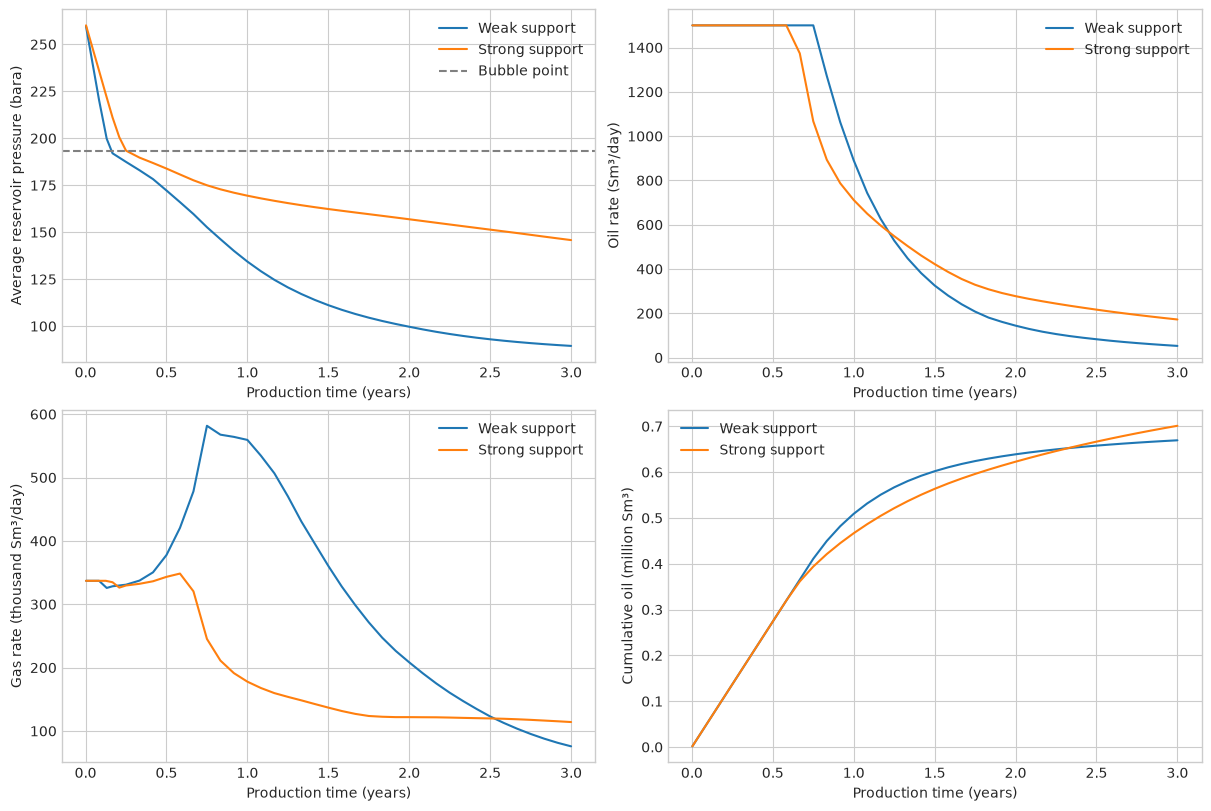

,case,final_pressure_bara,cumulative_oil_MSm3,peak_gas_thousand_Sm3_day,final_water_Sm3_day,first_average_bubble_crossing_day
0,Weak support,89.481094,0.669425,581.693665,44.181877,60.875
1,Strong support,145.798630,0.701109,348.449158,849.367371,121.750


In [17]:
figure, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
plot_specs = [
    ("pressure_bara", "Average reservoir pressure (bara)", 1.0),
    ("oil_Sm3_day", "Oil rate (Sm³/day)", 1.0),
    ("gas_Sm3_day", "Gas rate (thousand Sm³/day)", 1000.0),
    ("oil_cumulative_Sm3", "Cumulative oil (million Sm³)", 1e6),
]
for axis, (column, ylabel, scale) in zip(axes.flat, plot_specs):
    for label, history in scenario_histories.items():
        axis.plot(history["days"] / 365.25, history[column] / scale, label=label)
    axis.set(xlabel="Production time (years)", ylabel=ylabel)
    axis.legend()
axes[0, 0].axhline(bubble_pressure_bara, color="grey", linestyle="--", label="Bubble point")
axes[0, 0].legend()
show_figure(figure, "pressure_support_forecasts")

outcome_rows = []
for label, history in scenario_histories.items():
    crossed = history.loc[history["pressure_bara"] < bubble_pressure_bara, "days"]
    outcome_rows.append({
        "case": label, "final_pressure_bara": history["pressure_bara"].iloc[-1],
        "cumulative_oil_MSm3": history["oil_cumulative_Sm3"].iloc[-1] / 1e6,
        "peak_gas_thousand_Sm3_day": history["gas_Sm3_day"].max() / 1000,
        "final_water_Sm3_day": history["water_Sm3_day"].iloc[-1],
        "first_average_bubble_crossing_day": float(crossed.iloc[0]) if len(crossed) else None,
    })
outcomes = pd.DataFrame(outcome_rows)
display(outcomes)

## 8. Inspect spatial pressure and gas liberation

Restart arrays come directly from OPM Flow. Each panel shows the middle permeability layer at
the final report step. Gas saturation is the gas **pore-volume fraction**, unlike the mole-fraction
phase maps earlier. Cells may cross bubble pressure before the field-average pressure does.

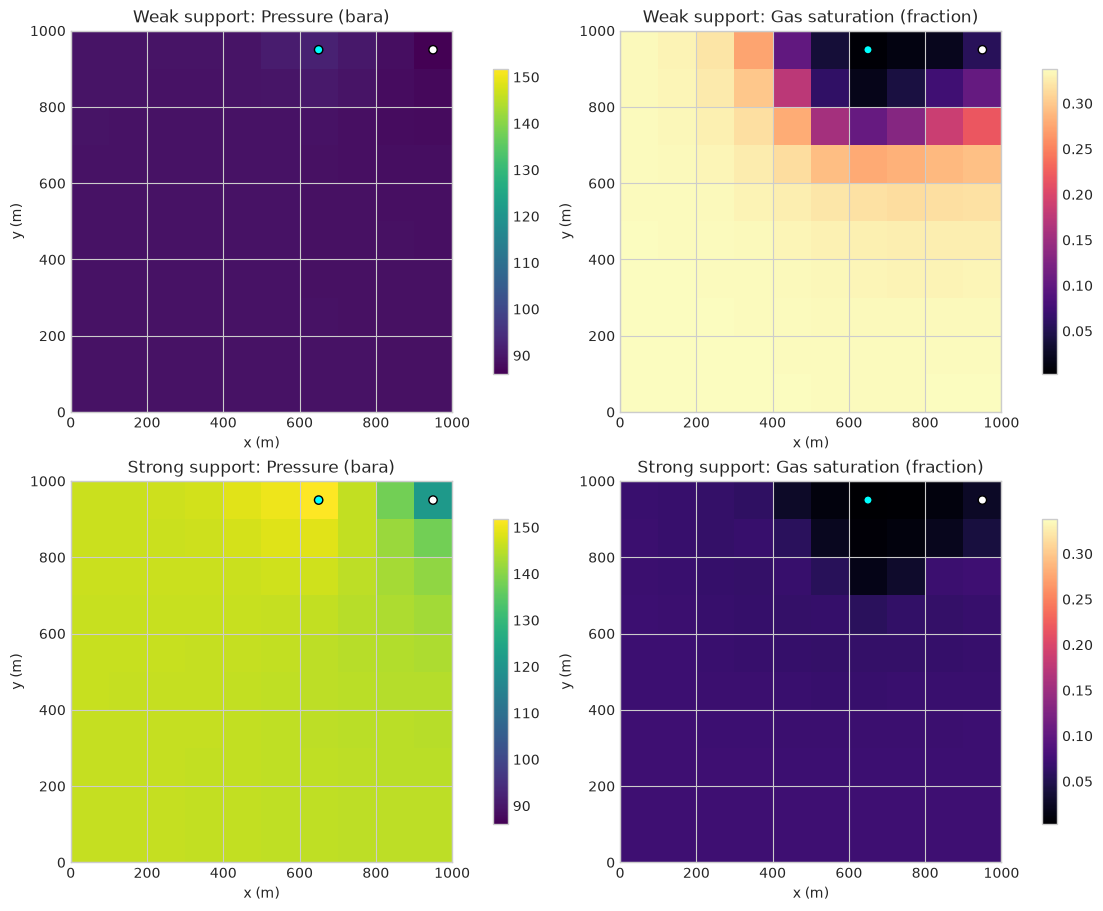

,case,active_cells,last_report_step,minimum_oil_saturation,maximum_gas_saturation,finite,saturations_valid
0,Weak support,300,36,0.184264,0.617070,True,True
1,Strong support,300,36,0.131675,0.486786,True,True


In [18]:
restart_states = {}
restart_checks = []
for label, directory in scenario_directories.items():
    grid = EGrid(str(directory / "NEQSIM_OPM.EGRID"))
    restart = ERst(str(directory / "NEQSIM_OPM.UNRST"))
    report_steps = list(restart.report_steps)
    last_step = int(report_steps[-1])
    pressure = np.asarray(restart["PRESSURE", last_step], dtype=float).reshape(3, 10, 10)
    water = np.asarray(restart["SWAT", last_step], dtype=float).reshape(3, 10, 10)
    gas = np.asarray(restart["SGAS", last_step], dtype=float).reshape(3, 10, 10)
    oil = 1.0 - water - gas
    restart_states[label] = {"pressure": pressure, "gas": gas, "water": water, "oil": oil}
    restart_checks.append({
        "case": label, "active_cells": int(grid.active_cells),
        "last_report_step": last_step, "minimum_oil_saturation": oil.min(),
        "maximum_gas_saturation": gas.max(),
        "finite": bool(np.isfinite(np.concatenate(
            [pressure.ravel(), gas.ravel(), water.ravel()]
        )).all()),
        "saturations_valid": bool(min(oil.min(), gas.min(), water.min()) >= -1e-6),
    })
figure, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
for row, (label, state) in enumerate(restart_states.items()):
    for column, (key, title, color_map) in enumerate([
        ("pressure", "Pressure (bara)", "viridis"),
        ("gas", "Gas saturation (fraction)", "magma"),
    ]):
        lower = min(item[key][1].min() for item in restart_states.values())
        upper = max(item[key][1].max() for item in restart_states.values())
        image = axes[row, column].imshow(
            state[key][1], origin="lower", extent=[0, 1000, 0, 1000],
            vmin=lower, vmax=upper, cmap=color_map,
        )
        axes[row, column].scatter([950, 650], [950, 950], c=["white", "cyan"], edgecolors="black")
        axes[row, column].set(title=f"{label}: {title}", xlabel="x (m)", ylabel="y (m)")
        figure.colorbar(image, ax=axes[row, column], shrink=0.8)
show_figure(figure, "reservoir_pressure_and_gas_maps")
display(pd.DataFrame(restart_checks))

## 9. Executable acceptance checks and reusable outputs

These checks cover equilibrium component closure, CCE conservation, CVD material and volume
balance, PVT/deck contracts, successful Flow execution, schedule completion, and physically
bounded reservoir outputs. Saturation-pressure agreement compares two NeqSim algorithms and is
not independent experimental validation. No field-history match is claimed.

In [19]:
checks = {
    "oil composition closes": abs(composition_sum - 1.0) < 1e-12,
    "TP component balance": maximum_component_residual < 1e-7,
    "phase fractions bounded": all(
        np.isfinite(array).all() and array.min() >= -1e-10 and array.max() <= 1.0 + 1e-10
        for array in phase_maps.values()
    ),
    "CCE volume rises with depletion": all(
        np.all(np.diff(values) >= -1e-7) for values in cce_results.values()
    ),
    "CVD material balance": cvd_balance_passed,
    "CVD cell volume restored": cvd_volume_error < 1e-7,
    "CVD nonzero retrograde dropout": cvd_table["liquid_volume_pct_Vsat"].max() > 0.0,
    "oil saturation methods agree": (
        abs(bubble_pressure_bara - bubble_pressure_reference_bara) < 0.2
    ),
    "PVT monotonicity and finite values": bool(pvt_contract_audit["passed"].all()),
    "required Flow keywords accepted": bool(deck_keyword_audit["present"].all()),
    "two real Flow runs succeeded": all(row["return_code"] == 0 for row in scenario_diagnostics),
    "complete 3-year schedule": all(
        abs(row["final_day"] - 1095.75) < 0.01 for row in scenario_diagnostics
    ),
    "finite reservoir histories": all(
        np.isfinite(table.to_numpy()).all() for table in scenario_histories.values()
    ),
    "nonnegative production rates": all(
        (table[["oil_Sm3_day", "gas_Sm3_day", "water_Sm3_day"]].to_numpy() >= -1e-8).all()
        for table in scenario_histories.values()
    ),
    "cumulative oil nondecreasing": all(
        np.all(np.diff(table["oil_cumulative_Sm3"]) >= -1e-6)
        for table in scenario_histories.values()
    ),
    "producer BHP limit respected": all(
        table["bhp_bara"].min() >= 79.99 for table in scenario_histories.values()
    ),
    "all 300 cells retained": all(row["active_cells"] == 300 for row in restart_checks),
    "restart states valid": all(
        row["finite"] and row["saturations_valid"] for row in restart_checks
    ),
}
validation = pd.DataFrame({
    "check": checks.keys(), "passed": [bool(value) for value in checks.values()]
})
display(validation)
assert validation["passed"].all(), validation.loc[~validation["passed"], "check"].tolist()
summary = {
    "issue": "https://github.com/equinor/neqsim/issues/4198",
    "source_commit": neqsim_commit, "jar_sha256": neqsim_jar_sha256,
    "opm_flow": flow_version_text,
    "synthetic_inputs": True,
    "oil_bubble_pressure_bara": float(bubble_pressure_bara),
    "condensate_dew_pressure_bara": float(cvd.getSaturationPressure()),
    "maximum_CVD_liquid_dropout_pct": float(cvd_table["liquid_volume_pct_Vsat"].max()),
    "CVD_material_balance_passed": cvd_balance_passed,
    "CVD_volume_relative_error": cvd_volume_error,
    "passed_checks": int(validation["passed"].sum()),
    "scenario_outcomes": outcomes.where(pd.notna(outcomes), None).to_dict("records"),
}
(OUTPUT_DIRECTORY / "results.json").write_text(json.dumps(summary, indent=2, allow_nan=False))
cvd_table.to_csv(OUTPUT_DIRECTORY / "cvd.csv", index=False)
cce_table.to_csv(OUTPUT_DIRECTORY / "cce.csv", index=False)
validation.to_csv(OUTPUT_DIRECTORY / "validation.csv", index=False)
archive_path = shutil.make_archive(str(OUTPUT_DIRECTORY), "zip", OUTPUT_DIRECTORY)
print(f"Passed {len(checks)} checks.")
print("Case decks, PVT tables, CSV results, logs and figures:", archive_path)

Passed 18 checks.
Case decks, PVT tables, CSV results, logs and figures: /workspace/scratch/bf0ebe8b6824/colab-4198/phase_evolution_4198_outputs.zip


,check,passed
0,oil composition closes,True
1,TP component balance,True
2,phase fractions bounded,True
3,CCE volume rises with depletion,True
4,CVD material balance,True
5,CVD cell volume restored,True
6,CVD nonzero retrograde dropout,True
7,oil saturation methods agree,True
8,PVT monotonicity and finite values,True
9,required Flow keywords accepted,True


## Interpretation and how to extend this toward issue #4198

1. **Composition matters.** Oil and gas-condensate phase maps differ even under the same pressure and
   temperature. A phase label alone does not specify composition, density, or a migration pathway.
2. **Depletion history matters.** CCE retains all components; CVD preferentially removes equilibrium gas.
   Consequently, a fixed-composition phase envelope cannot replace an open-system depletion calculation.
3. **Pressure support changes the production path.** Compare the actual pressure, oil, gas, water, and
   spatial gas-saturation results above. Injection targets are constrained by injector BHP; they are
   not guaranteed achieved rates. This small example does not establish an optimum development plan.
4. **Choose the reservoir representation carefully.** The oil black-oil deck demonstrates the interface.
   Near-critical oils, gas condensates, gas injection, and evolving source compositions require further
   PVT qualification and often compositional transport. NeqSim alone does not simulate basin migration.

For a study extending the cited paper, obtain published or authorized fluid compositions, PVT
measurements, burial-temperature and pressure histories, source-rock maturation models, migration
pathways, permeability/fault histories, and initial/boundary conditions. Calibrate EOS/heavy fractions,
run uncertainty on those inputs, qualify the chosen reservoir formulation, and compare against
independent observations. Geological-time source generation and migration remain separate modeling tasks.

**Exercises:** change the condensate C10/C16 content; rerun the CVD at another temperature; change
permeability contrast or injection rate; and refine the grid/time steps to quantify numerical sensitivity.
Keep the printed acceptance checks and source provenance with every result.

## References and related executable examples

- [Issue #4198](https://github.com/equinor/neqsim/issues/4198): scope and research motivation.
- [Xu et al. (2025), Applied Sciences 15, 9694](https://doi.org/10.3390/app15179694): motivating paper;
  no field input data were copied from it.
- [NeqSim source](https://github.com/equinor/neqsim): `SaturationPressure`, `ConstantMassExpansion`,
  `ConstantVolumeDepletion`, and `DifferentialLiberation` implementations.
- [OPM Flow installation](https://opm-project.org/?page_id=245) and
  [OPM Python documentation](https://opm.github.io/opm-python-documentation/).
- [Rasmussen et al., The Open Porous Media Flow Reservoir Simulator](https://arxiv.org/abs/1910.06059).
- [NeqSim–OPM black-oil coupling](neqsim_opm_flow_blackoil_coupling.ipynb): source workflow adapted for
  the oil-sector handoff; includes surface-process reconstruction.
- [PVT laboratory workflow](../PVT/pvt_workflow_from_lab_to_simulator.ipynb).

Validation evidence: all code cells must execute in sequence with stored outputs; generated HTML,
all equations and every figure are inspected before publication. Numerical results are synthetic
and internally checked, without experimental accuracy or geological-history validation claims.

In the retained synthetic run, stronger support raises cumulative oil from 0.6694 to
0.7011 million Sm³ (about 4.7%) and final average pressure from 89.5 to 145.8 bara.
Final water production rises from 44.2 to 849.4 Sm³/day. These results illustrate the
pressure-support/water-handling tradeoff; they are not a forecast for the Mo-Yong reservoirs.
